In [6]:
!pip install shap -q

In [7]:
import shap
import joblib

In [8]:
model = joblib.load("xgboost_multiclass.pkl")

In [9]:
explainer = shap.TreeExplainer(model)

In [14]:
import kagglehub
path = kagglehub.dataset_download("ericanacletoribeiro/cicids2017-cleaned-and-preprocessed")

Using Colab cache for faster access to the 'cicids2017-cleaned-and-preprocessed' dataset.


In [16]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/cicids2017-cleaned-and-preprocessed/cicids2017_cleaned.csv"
)

In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Attack Type"] = encoder.fit_transform(
    df["Attack Type"]
)

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop("Attack Type", axis=1)
y = df["Attack Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
sample = X_test.sample(
    1000,
    random_state=42
)

In [20]:
shap_values = explainer.shap_values(sample)

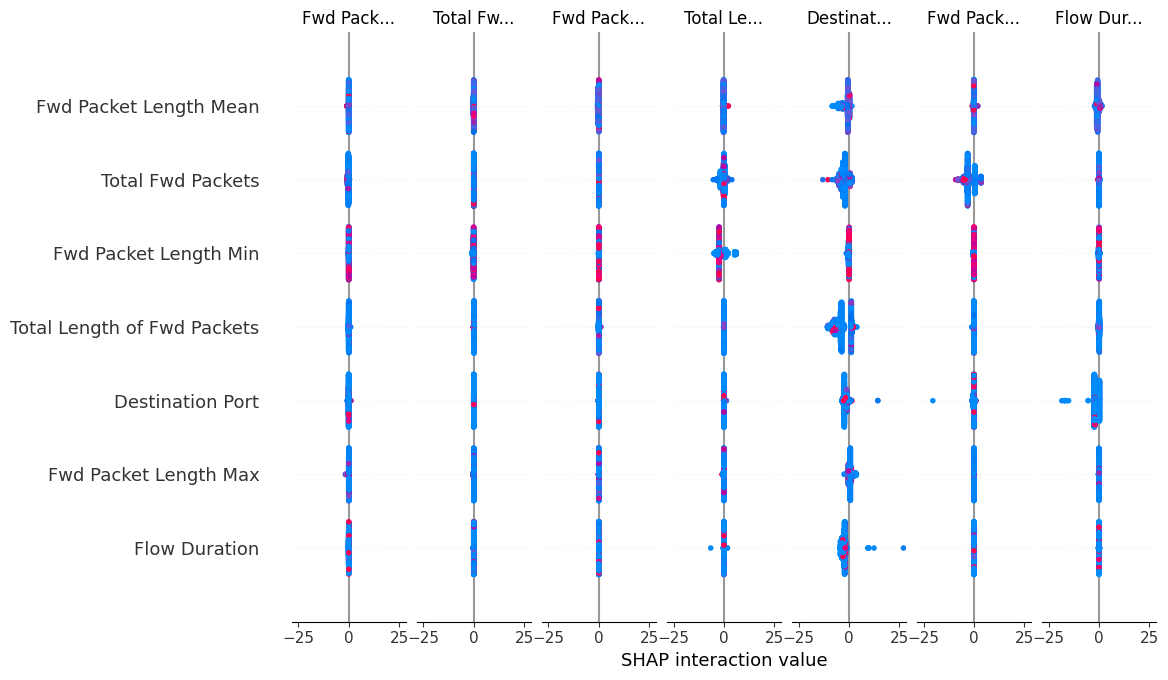

In [21]:
shap.summary_plot(
    shap_values,
    sample
)